# 03 · Análise Exploratória (EDA) com foco em negócio

**Tech Challenge Fase 1 · NPS Preditivo**

Este notebook responde às quatro perguntas do desafio, pensando em **um(a) gerente de operações que não entende estatística**:

1. Quais fatores parecem mais críticos para a satisfação?
2. O que mais gera detratores?
3. Existe algum "ponto de ruptura" na experiência do cliente?
4. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

**Como ler os números:**
- **Nota média:** média das notas de 0 a 10 que os clientes deram.
- **% de detratores:** a cada 100 clientes, quantos deram nota abaixo de 7 (clientes insatisfeitos, que tendem a falar mal da marca).
- **NPS:** % de promotores (nota 9 ou 10) menos % de detratores. Vai de −100 (todos insatisfeitos) a +100 (todos fãs).

Base usada: `data/processed/nps_tratado.csv`, gerada no notebook `02_preparacao_dados.ipynb`.

## Configuração

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats

# Permite importar o pacote src/ tanto a partir de notebooks/ quanto da raiz do projeto
sys.path.append(
    str(Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve())
)

from src.preparacao import (  # noqa: E402 (precisa vir depois do sys.path)
    JORNADA_CRITICA,
    JORNADA_PERFEITA,
    LIMITE_NEUTRO,
    RAIZ_PROJETO,
    calcular_nps,
    carregar_base_tratada,
)

PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Limiares de leitura usados nos gráficos. O "porquê" de cada um:
LIMIAR_FORCA_RELEVANTE = 0.15  # abaixo disso a relação é fraca demais para orientar uma ação
PCT_DETRATORES_CRITICO = 90  # "9 em cada 10": situação em que a experiência está perdida
PCT_DETRATORES_SATURACAO = 95  # a partir daqui dizemos que "praticamente todos" viram detratores
N_MINIMO_CELULA = 30  # células do mapa de calor com menos clientes que isso não são mostradas
N_BOOTSTRAP = 2000  # reamostragens para o intervalo de confiança do NPS
SEMENTE = 42  # torna o bootstrap reproduzível
NIVEL_SIGNIFICANCIA = 0.05  # p-valor abaixo disso = diferença maior do que o acaso explicaria

# Paleta única no projeto inteiro (os mesmos tons vão para os slides)
COR_DETRATOR = "#D1495B"
COR_NEUTRO = "#A0A4A8"
COR_PROMOTOR = "#2E9E6B"
COR_DESTAQUE = COR_DETRATOR  # o destaque dos gráficos é sempre "o que gera detrator"
COR_BASE = "#6C8EBF"

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = carregar_base_tratada()

# Nas análises que usam o PRAZO TOTAL, deixamos de fora os 121 pedidos cujo prazo foi imputado
# no notebook 02: um valor estimado não pode gerar um padrão "real" no gráfico.
df_prazo_confiavel = df[df["flag_inconsistencia_prazo"] == 0]

print(f"{len(df)} pedidos carregados ({len(df_prazo_confiavel)} com prazo total confiável)")

2500 pedidos carregados (2379 com prazo total confiável)


In [2]:
def resumo_por_grupo(coluna_grupo: str, dados: pd.DataFrame | None = None) -> pd.DataFrame:
    """Quantidade de clientes, nota média, % de detratores e NPS de cada grupo.

    Args:
        coluna_grupo: Coluna categórica que define os grupos.
        dados: Base a resumir (padrão: todos os pedidos).
    """
    dados = df if dados is None else dados
    agrupado = dados.groupby(coluna_grupo, observed=True)
    return pd.DataFrame(
        {
            "clientes": agrupado.size(),
            "nota_media": agrupado["nps_score"].mean().round(1),
            "pct_detratores": (agrupado["flag_detrator"].mean() * 100).round(0),
            "nps": agrupado["nps_score"].apply(calcular_nps),
        }
    )


def salvar_figura(nome_arquivo: str) -> None:
    """Salva o gráfico em reports/figures para reaproveitar nos slides."""
    plt.tight_layout()
    plt.savefig(PASTA_FIGURAS / nome_arquivo, dpi=150, bbox_inches="tight")

## 0. Retrato atual: como está a satisfação hoje?

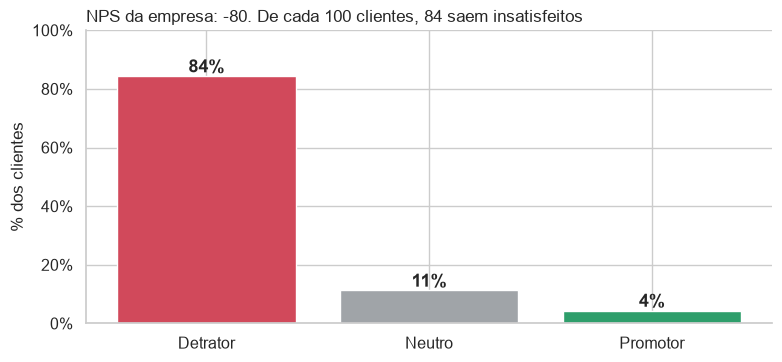

In [3]:
nps_geral = calcular_nps(df["nps_score"])
distribuicao = df["nps_categoria"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(8, 3.8))
barras = ax.bar(
    distribuicao.index, distribuicao.values, color=[COR_DETRATOR, COR_NEUTRO, COR_PROMOTOR]
)
ax.bar_label(
    barras, labels=[f"{v:.0f}%" for v in distribuicao.values], fontsize=13, fontweight="bold"
)
ax.set_title(
    f"NPS da empresa: {nps_geral:.0f}. "
    f"De cada 100 clientes, {distribuicao['Detrator']:.0f} saem insatisfeitos",
    loc="left",
    fontsize=12,
)
ax.set_ylabel("% dos clientes")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
salvar_figura("03_01_retrato_nps.png")
plt.show()

**Para o gerente:** a situação é crítica. **84 de cada 100 clientes** saem insatisfeitos e só **4** viram fãs da marca. O NPS de **−80** está muito abaixo do que se considera saudável no varejo (em geral, acima de zero já é razoável e acima de +50 é excelente).

## 1. Quais fatores parecem mais críticos para a satisfação?

Medimos a **força da relação** de cada informação da operação com a nota do cliente. A escala vai de 0 (nenhuma relação) a 1 (relação perfeita). Estatisticamente é o módulo da correlação de Pearson, mas o gerente só precisa saber que **barra maior = fator que mais mexe com a nota**.

> `csat_internal_score` e `repeat_purchase_30d` ficam de fora: são **outras medidas da satisfação**, não causas dela (notebook 02, seção 9). Para o **prazo total de entrega**, usamos só os 2.379 pedidos sem imputação (notebook 02, seção 5.1).


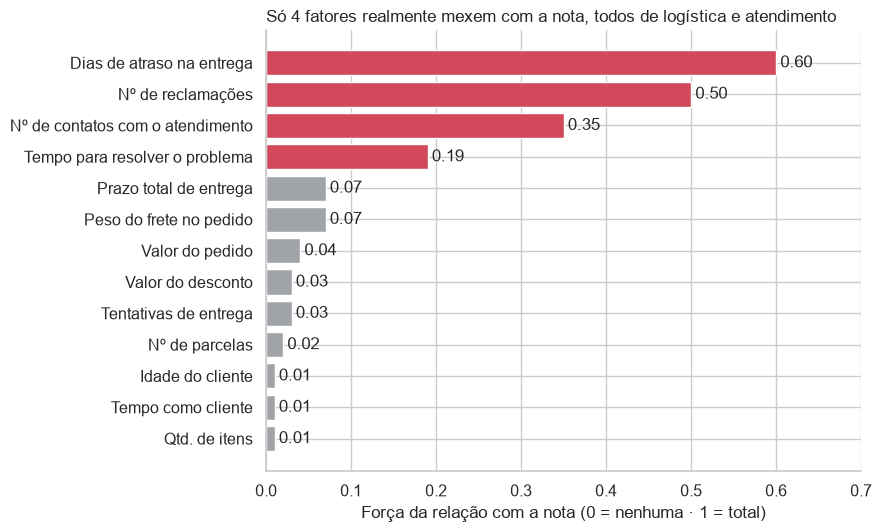

,fator,area,correlacao,forca_relacao
0,Dias de atraso na entrega,Logística,-0.597,0.60
1,Nº de reclamações,Atendimento,-0.497,0.50
2,Nº de contatos com o atendimento,Atendimento,-0.351,0.35
3,Tempo para resolver o problema,Atendimento,-0.191,0.19
4,Peso do frete no pedido,Pedido,-0.067,0.07
5,Prazo total de entrega,Logística,-0.065,0.07
6,Valor do pedido,Pedido,0.037,0.04
7,Tentativas de entrega,Logística,0.028,0.03
8,Valor do desconto,Pedido,0.025,0.03
9,Nº de parcelas,Pedido,0.024,0.02


In [4]:
FATORES = {
    "delivery_delay_days": ("Dias de atraso na entrega", "Logística"),
    "complaints_count": ("Nº de reclamações", "Atendimento"),
    "customer_service_contacts": ("Nº de contatos com o atendimento", "Atendimento"),
    "resolution_time_days": ("Tempo para resolver o problema", "Atendimento"),
    "pct_frete": ("Peso do frete no pedido", "Pedido"),
    "delivery_time_days": ("Prazo total de entrega", "Logística"),
    "delivery_attempts": ("Tentativas de entrega", "Logística"),
    "order_value": ("Valor do pedido", "Pedido"),
    "payment_installments": ("Nº de parcelas", "Pedido"),
    "discount_value": ("Valor do desconto", "Pedido"),
    "items_quantity": ("Qtd. de itens", "Pedido"),
    "customer_age": ("Idade do cliente", "Perfil"),
    "customer_tenure_months": ("Tempo como cliente", "Perfil"),
}

correlacoes = df[list(FATORES) + ["nps_score"]].corr()["nps_score"].drop("nps_score")
# O prazo total é calculado só nos pedidos sem imputação (ver nota acima)
correlacoes["delivery_time_days"] = df_prazo_confiavel["delivery_time_days"].corr(
    df_prazo_confiavel["nps_score"]
)

ranking = pd.DataFrame(
    {
        "coluna": correlacoes.index,
        "fator": [FATORES[c][0] for c in correlacoes.index],
        "area": [FATORES[c][1] for c in correlacoes.index],
        "correlacao": correlacoes.values.round(3),
        "forca_relacao": correlacoes.abs().values.round(2),
    }
).sort_values("forca_relacao", ascending=True)
fatores_relevantes = ranking[ranking["forca_relacao"] >= LIMIAR_FORCA_RELEVANTE]

fig, ax = plt.subplots(figsize=(9, 5.5))
cores = [
    COR_DESTAQUE if f >= LIMIAR_FORCA_RELEVANTE else COR_NEUTRO for f in ranking["forca_relacao"]
]
barras = ax.barh(ranking["fator"], ranking["forca_relacao"], color=cores)
ax.bar_label(barras, labels=[f"{v:.2f}" for v in ranking["forca_relacao"]], padding=3)
ax.set_title(
    f"Só {len(fatores_relevantes)} fatores realmente mexem com a nota, "
    f"todos de {' e '.join(fatores_relevantes['area'].str.lower().unique()[::-1])}",
    loc="left",
    fontsize=12,
)
ax.set_xlabel("Força da relação com a nota (0 = nenhuma · 1 = total)")
ax.set_xlim(0, 0.7)
salvar_figura("03_02_ranking_fatores.png")
plt.show()

ranking.drop(columns="coluna").sort_values("forca_relacao", ascending=False).reset_index(drop=True)

**Para o gerente:** quatro fatores concentram praticamente toda a relação com a satisfação, e **todos acontecem depois que o cliente clica em "comprar"**:

| # | Fator | Área responsável |
|---|---|---|
| 1 | **Atraso na entrega** | Logística |
| 2 | **Reclamações** | Atendimento / Qualidade |
| 3 | **Contatos repetidos com o atendimento** | Atendimento |
| 4 | **Demora para resolver o problema** | Atendimento |

Já preço, desconto, parcelamento, frete, quantidade de itens, idade e tempo de casa **praticamente não fazem diferença**. Os quatro fatores têm relação **negativa**: quanto mais atraso, reclamação ou contato, menor a nota.

### Um detalhe que muda a estratégia: prazo longo ≠ atraso

O **prazo total** de entrega quase não afeta a nota (0,07), mas o **atraso** é o fator nº 1 (0,60). Comparando lado a lado:

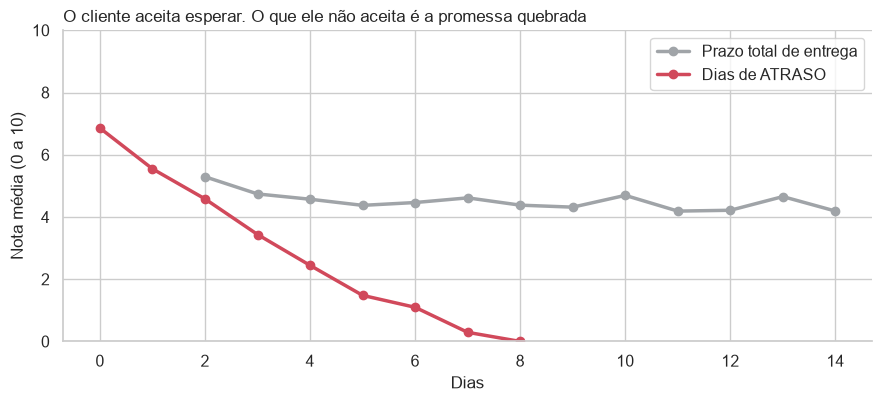

In [5]:
# Prazo total: só pedidos sem imputação. Atraso: todos (a coluna de atraso não foi alterada)
nota_por_prazo = df_prazo_confiavel.groupby("delivery_time_days")["nps_score"].mean()
nota_por_atraso = df.groupby("delivery_delay_days")["nps_score"].mean()

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(
    nota_por_prazo.index,
    nota_por_prazo.values,
    "o-",
    color=COR_NEUTRO,
    lw=2.5,
    label="Prazo total de entrega",
)
ax.plot(
    nota_por_atraso.index,
    nota_por_atraso.values,
    "o-",
    color=COR_DESTAQUE,
    lw=2.5,
    label="Dias de ATRASO",
)
ax.set_title(
    "O cliente aceita esperar. O que ele não aceita é a promessa quebrada", loc="left", fontsize=12
)
ax.set_xlabel("Dias")
ax.set_ylabel("Nota média (0 a 10)")
ax.set_ylim(0, 10)
ax.legend()
salvar_figura("03_03_prazo_vs_atraso.png")
plt.show()

**Para o gerente:** entre 2 e 14 dias de prazo total, a nota média **praticamente não muda**: quem recebe em 14 dias dá quase a mesma nota de quem recebe em 2. Já **cada dia de atraso derruba a nota**. A lição é **prometer um prazo que dá para cumprir**, e não necessariamente entregar mais rápido.

> Nota técnica: a linha do prazo total usa só os 2.379 pedidos sem imputação. Com os 121 imputados (todos com 8 dias e nota muito baixa), apareceria um "vale" artificial em 8 dias que não existe nos dados originais.


### Os quatro fatores juntos: quanto explicam e quanto pesa cada um?

O ranking olha um fator de cada vez. Uma **regressão linear múltipla** (Estatística, Aula 3) responde duas perguntas que o ranking não responde: **quanto os fatores explicam juntos** (R²) e **quanto cada um pesa, descontando os outros** (coeficientes). Para o gerente, o coeficiente é "quantos pontos a nota perde a cada dia de atraso / a cada reclamação a mais".


In [6]:
colunas_principais = fatores_relevantes["coluna"].tolist()

X = np.c_[np.ones(len(df)), df[colunas_principais].values]  # coluna de 1s = intercepto
y = df["nps_score"].values
coeficientes, *_ = np.linalg.lstsq(X, y, rcond=None)
previsto = X @ coeficientes
r2_fatores = 1 - ((y - previsto) ** 2).sum() / ((y - y.mean()) ** 2).sum()

print(
    f"Juntos, os {len(colunas_principais)} fatores explicam {r2_fatores:.0%} "
    "da variação da nota (R²)\n"
)
efeitos = pd.DataFrame(
    {
        "fator": [FATORES[c][0] for c in colunas_principais],
        "efeito_na_nota_por_unidade": coeficientes[1:].round(2),
    }
).sort_values("efeito_na_nota_por_unidade")
display(efeitos.reset_index(drop=True))

# Os fatores são independentes entre si? (se fossem muito correlacionados, "somar" os efeitos
# seria enganoso)
print("\nCorrelação entre os fatores:")
df[colunas_principais].rename(columns={c: FATORES[c][0] for c in FATORES}).corr().round(2)

Juntos, os 4 fatores explicam 56% da variação da nota (R²)



,fator,efeito_na_nota_por_unidade
0,Dias de atraso na entrega,-0.95
1,Nº de reclamações,-0.38
2,Nº de contatos com o atendimento,-0.32
3,Tempo para resolver o problema,-0.14



Correlação entre os fatores:


,Tempo para resolver o problema,Nº de contatos com o atendimento,Nº de reclamações,Dias de atraso na entrega
Tempo para resolver o problema,1.00,0.01,0.02,-0.02
Nº de contatos com o atendimento,0.01,1.00,0.75,-0.02
Nº de reclamações,0.02,0.75,1.00,0.19
Dias de atraso na entrega,-0.02,-0.02,0.19,1.00


**Para o gerente:** os quatro fatores juntos explicam **56% da variação da nota**: mais da metade do que faz um cliente dar nota alta ou baixa está em coisas que a operação controla. Descontando os outros fatores, **cada dia de atraso custa cerca de 1 ponto** na nota (0 a 10), cada reclamação custa 0,4 ponto, cada contato a mais com o atendimento 0,3 ponto e cada dia a mais para resolver 0,14 ponto.

A matriz de correlação mostra dois tipos de relação entre os fatores:
- **Atraso é independente** de reclamações (0,19) e de contatos (−0,02): são problemas diferentes, que atingem clientes diferentes e **se somam** quando acontecem juntos (ver o mapa de calor na seção 2).
- **Reclamações e contatos andam juntos** (0,75): são dois sinais do **mesmo problema de atendimento**. Por isso, na regressão, o efeito do atendimento se divide entre os dois (0,4 + 0,3), e na prática devem ser tratados como uma frente só: resolver no primeiro contato.


## 2. O que mais gera detratores?

Olhamos agora o **% de detratores** em cada situação: a cada 100 clientes naquela situação, quantos saem insatisfeitos.

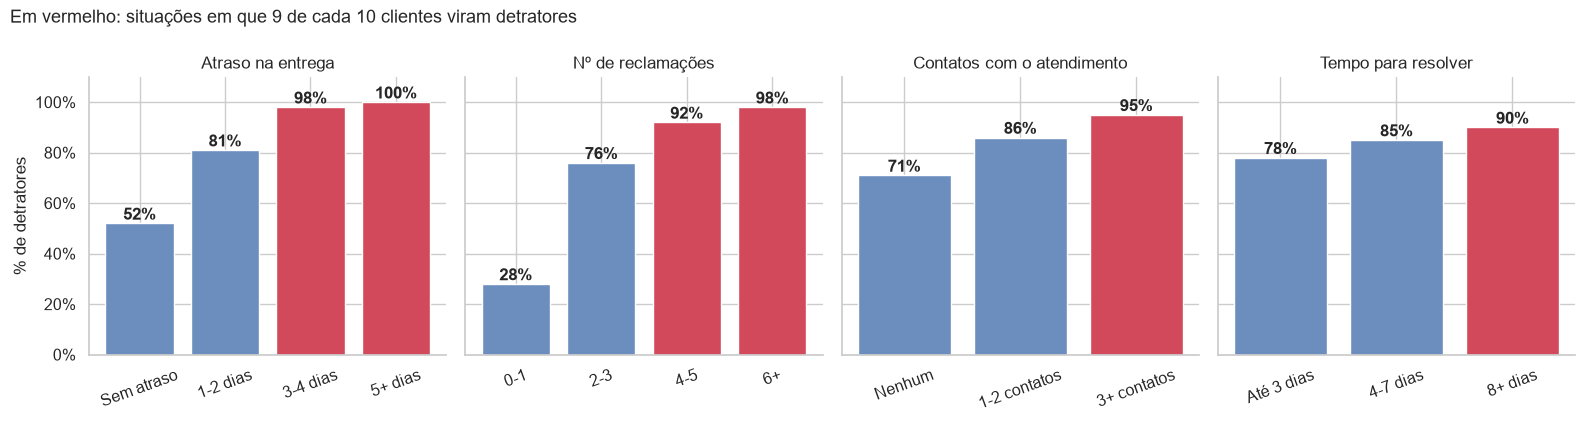

In [7]:
# As faixas de reclamações e de resolução já vêm da base tratada (src/preparacao.py, FAIXAS)
paineis = [
    ("faixa_atraso", "Atraso na entrega"),
    ("faixa_reclamacoes", "Nº de reclamações"),
    ("faixa_contatos", "Contatos com o atendimento"),
    ("faixa_resolucao", "Tempo para resolver"),
]

fig, eixos = plt.subplots(1, 4, figsize=(16, 4.3), sharey=True)
for eixo, (coluna, titulo) in zip(eixos, paineis):
    tabela = resumo_por_grupo(coluna)
    cores = [
        COR_DESTAQUE if p >= PCT_DETRATORES_CRITICO else COR_BASE for p in tabela["pct_detratores"]
    ]
    barras = eixo.bar(tabela.index.astype(str), tabela["pct_detratores"], color=cores)
    eixo.bar_label(
        barras, labels=[f"{v:.0f}%" for v in tabela["pct_detratores"]], fontweight="bold"
    )
    eixo.set_title(titulo)
    eixo.set_ylim(0, 110)
    eixo.yaxis.set_major_formatter(mtick.PercentFormatter())
    eixo.tick_params(axis="x", rotation=20)
eixos[0].set_ylabel("% de detratores")
fig.suptitle(
    "Em vermelho: situações em que 9 de cada 10 clientes viram detratores",
    x=0.01,
    ha="left",
    fontsize=13,
)
salvar_figura("03_04_geradores_detratores.png")
plt.show()

In [8]:
for coluna, titulo in paineis:
    print(f"--- {titulo} ---")
    display(resumo_por_grupo(coluna))

--- Atraso na entrega ---


,clientes,nota_media,pct_detratores,nps
faixa_atraso,,,,
Sem atraso,277,6.9,52.0,-33.6
1-2 dias,1261,5.1,81.0,-76.6
3-4 dias,795,3.1,98.0,-97.2
5+ dias,167,1.3,100.0,-100.0


--- Nº de reclamações ---


,clientes,nota_media,pct_detratores,nps
faixa_reclamacoes,,,,
0-1,145,7.9,28.0,-4.1
2-3,784,5.3,76.0,-69.0
4-5,1044,4.0,92.0,-89.9
6+,527,2.8,98.0,-97.3


--- Contatos com o atendimento ---


,clientes,nota_media,pct_detratores,nps
faixa_contatos,,,,
Nenhum,554,5.5,71.0,-60.5
1-2 contatos,1456,4.4,86.0,-82.6
3+ contatos,490,2.9,95.0,-94.3


--- Tempo para resolver ---


,clientes,nota_media,pct_detratores,nps
faixa_resolucao,,,,
Até 3 dias,866,4.9,78.0,-70.6
4-7 dias,792,4.4,85.0,-81.8
8+ dias,842,3.8,90.0,-87.9


**Para o gerente:**
- **Atraso:** sem atraso, metade dos clientes (52%) ainda sai insatisfeita. Com **3 dias ou mais**, **97 a 100%** saem insatisfeitos.
- **Reclamações:** quem registra 0 ou 1 reclamação tem NPS perto de zero (−4). A partir de **4 reclamações**, 92% viram detratores.
- **Contatos com o atendimento:** quem **não precisou** ligar tem NPS de −61. Com **3 ou mais contatos**, 95% são detratores. Cada vez que o cliente precisa voltar ao atendimento, a satisfação cai.
- **Tempo de resolução:** tem efeito menor, mas constante. Resolver em até 3 dias rende NPS de −71, contra −88 quando passa de uma semana.

### Os problemas se somam: o efeito bola de neve

Atraso e reclamações são problemas **quase independentes** (um não explica o outro). Quando acontecem juntos, o estrago se acumula:

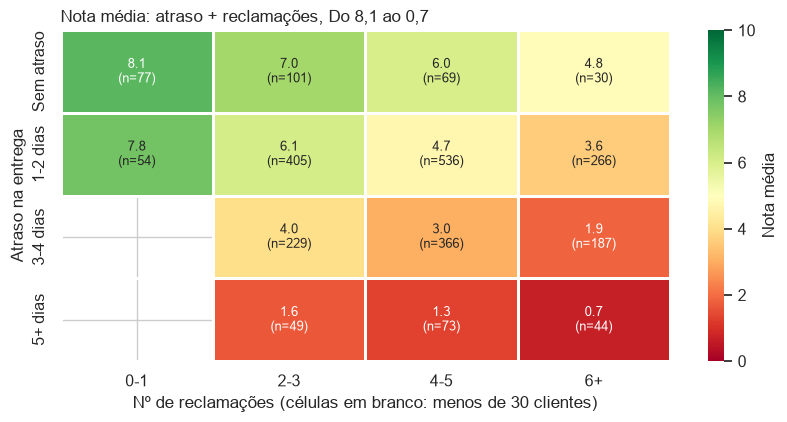

In [9]:
mapa_combinado = pd.crosstab(
    df["faixa_atraso"], df["faixa_reclamacoes"], values=df["nps_score"], aggfunc="mean"
)
clientes_por_celula = pd.crosstab(df["faixa_atraso"], df["faixa_reclamacoes"])

# Células com poucos clientes não são mostradas: a média de 1 ou 13 pessoas não é confiável
poucos_clientes = clientes_por_celula < N_MINIMO_CELULA
mapa_confiavel = mapa_combinado.where(~poucos_clientes)
rotulos = mapa_combinado.round(1).astype(str) + "\n(n=" + clientes_por_celula.astype(str) + ")"

fig, ax = plt.subplots(figsize=(8.5, 4.4))
sns.heatmap(
    mapa_confiavel,
    annot=rotulos,
    fmt="",
    mask=poucos_clientes,
    cmap="RdYlGn",
    vmin=0,
    vmax=10,
    cbar_kws={"label": "Nota média"},
    linewidths=1,
    annot_kws={"fontsize": 9},
    ax=ax,
)
ax.set_title(
    f"Nota média: atraso + reclamações. Do {mapa_confiavel.max().max():.1f} "
    f"ao {mapa_confiavel.min().min():.1f}".replace(".", ","),
    loc="left",
    fontsize=12,
)
ax.set_xlabel(f"Nº de reclamações (células em branco: menos de {N_MINIMO_CELULA} clientes)")
ax.set_ylabel("Atraso na entrega")
salvar_figura("03_05_efeito_combinado.png")
plt.show()

**Para o gerente:** o pedido **entregue no prazo e sem reclamação** recebe nota média **8,1**. O pedido **com 5+ dias de atraso e 6+ reclamações** recebe **0,7**. Resolver só um dos problemas já ajuda, mas o maior ganho vem de atacar os dois ao mesmo tempo.

Cada célula mostra também quantos clientes ela tem (`n`). As combinações raras (ex.: muito atraso com nenhuma reclamação) ficam em branco: com menos de 30 clientes, a média não é confiável.


## 3. Existe um "ponto de ruptura"?

Ponto de ruptura é o momento em que a experiência **deixa de ser recuperável**, quando praticamente todo cliente vira detrator. Para encontrá-lo, olhamos dia a dia de atraso de dois jeitos: a **nota média** (mostra se a queda é gradual ou em degrau) e o **% de detratores** (mostra quando "praticamente todos" já cruzaram a linha da nota 7).


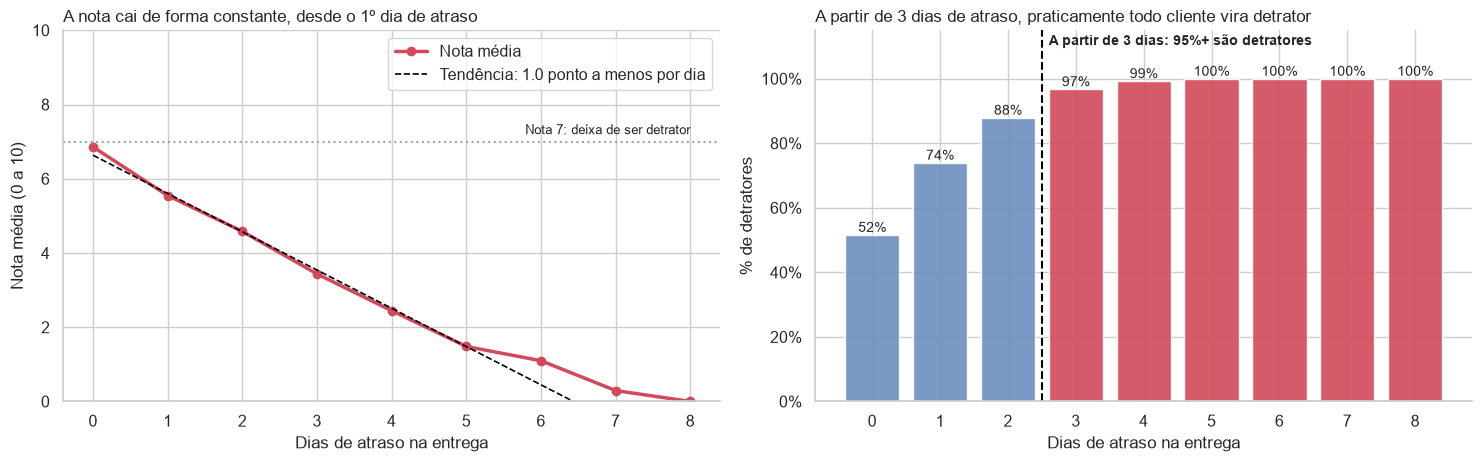

,clientes,nota_media,pct_detratores,salto_pct_detratores
delivery_delay_days,,,,
0,277,6.9,51.6,NaN
1,615,5.5,74.0,22.4
2,646,4.6,87.9,13.9
3,525,3.4,96.8,8.8
4,270,2.4,99.3,2.5
5,116,1.5,100.0,0.7
6,34,1.1,100.0,0.0
7,14,0.3,100.0,0.0
8,3,0.0,100.0,0.0


In [10]:
por_dia_atraso = df.groupby("delivery_delay_days").agg(
    clientes=("nps_score", "size"),
    nota_media=("nps_score", "mean"),
    pct_detratores=("flag_detrator", "mean"),
)
por_dia_atraso["pct_detratores"] *= 100
por_dia_atraso["salto_pct_detratores"] = por_dia_atraso["pct_detratores"].diff()
dias = por_dia_atraso.index.to_numpy()

# Reta de tendência: quantos pontos a nota perde por dia de atraso
queda_por_dia, nota_sem_atraso = np.polyfit(df["delivery_delay_days"], df["nps_score"], 1)

# Primeiro dia em que "praticamente todos" (95%+) são detratores
dia_saturacao = int(dias[por_dia_atraso["pct_detratores"] >= PCT_DETRATORES_SATURACAO][0])

fig, (ax_nota, ax_pct) = plt.subplots(1, 2, figsize=(15, 4.8))

# Painel 1: nota média por dia de atraso + tendência
ax_nota.plot(
    dias, por_dia_atraso["nota_media"], "o-", color=COR_DESTAQUE, lw=2.5, label="Nota média"
)
ax_nota.plot(
    dias,
    nota_sem_atraso + queda_por_dia * dias,
    "--",
    color="black",
    lw=1.2,
    label=f"Tendência: {abs(queda_por_dia):.1f} ponto a menos por dia",
)
ax_nota.axhline(LIMITE_NEUTRO, color=COR_NEUTRO, ls=":", lw=1.5)
ax_nota.text(dias[-1], LIMITE_NEUTRO + 0.2, "Nota 7: deixa de ser detrator", ha="right", fontsize=9)
ax_nota.set_title(
    "A nota cai de forma constante, desde o 1º dia de atraso", loc="left", fontsize=12
)
ax_nota.set_xlabel("Dias de atraso na entrega")
ax_nota.set_ylabel("Nota média (0 a 10)")
ax_nota.set_ylim(0, 10)
ax_nota.set_xticks(dias)
ax_nota.legend(loc="upper right")

# Painel 2: % de detratores por dia de atraso
cores = [COR_DESTAQUE if d >= dia_saturacao else COR_BASE for d in dias]
barras = ax_pct.bar(dias, por_dia_atraso["pct_detratores"], color=cores, alpha=0.9)
ax_pct.bar_label(
    barras, labels=[f"{v:.0f}%" for v in por_dia_atraso["pct_detratores"]], fontsize=10
)
ax_pct.axvline(dia_saturacao - 0.5, color="black", ls="--", lw=1.5)
ax_pct.annotate(
    f"A partir de {dia_saturacao} dias: {PCT_DETRATORES_SATURACAO}%+ são detratores",
    xy=(dia_saturacao - 0.4, 0.96),
    xycoords=("data", "axes fraction"),
    fontweight="bold",
    fontsize=10,
)
ax_pct.set_title(
    f"A partir de {dia_saturacao} dias de atraso, praticamente todo cliente vira detrator",
    loc="left",
    fontsize=12,
)
ax_pct.set_xlabel("Dias de atraso na entrega")
ax_pct.set_ylabel("% de detratores")
ax_pct.set_ylim(0, 115)
ax_pct.set_yticks(range(0, 101, 20))
ax_pct.set_xticks(dias)
ax_pct.yaxis.set_major_formatter(mtick.PercentFormatter())
salvar_figura("03_06_ponto_ruptura_atraso.png")
plt.show()

por_dia_atraso.round(1)

**Para o gerente:** o ponto de ruptura existe, mas **não é um degrau: é o fim de uma ladeira**.

- **A nota cai cerca de 1 ponto por dia de atraso, desde o primeiro dia** (6,9 sem atraso → 5,5 com 1 dia → 4,6 com 2 dias → 3,4 com 3 dias). A queda é constante, sem um dia "especial". E o **maior salto no % de detratores é do dia 0 para o dia 1** (de 52% para 74%).
- **A partir de 3 dias de atraso, 97% ou mais viram detratores**, e de 5 dias em diante são 100%. Esse é o ponto de ruptura: a nota média cruza a linha do 7 e praticamente ninguém mais se recupera.

Na prática, **a ação precisa começar no 1º dia de atraso, não no 3º**. Avisar o cliente, oferecer compensação ou priorizar a entrega no primeiro dia evita a maior parte da perda. Esperar o 3º dia é agir quando já não há mais o que recuperar.

O atendimento tem comportamento parecido nas **reclamações**: com 0 ou 1 reclamação, cerca de 30% viram detratores, e **com 2 já são 65%**. Nos **contatos** a piora é gradual, sem um salto único, e passa de 90% a partir do 3º contato.


## 4. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

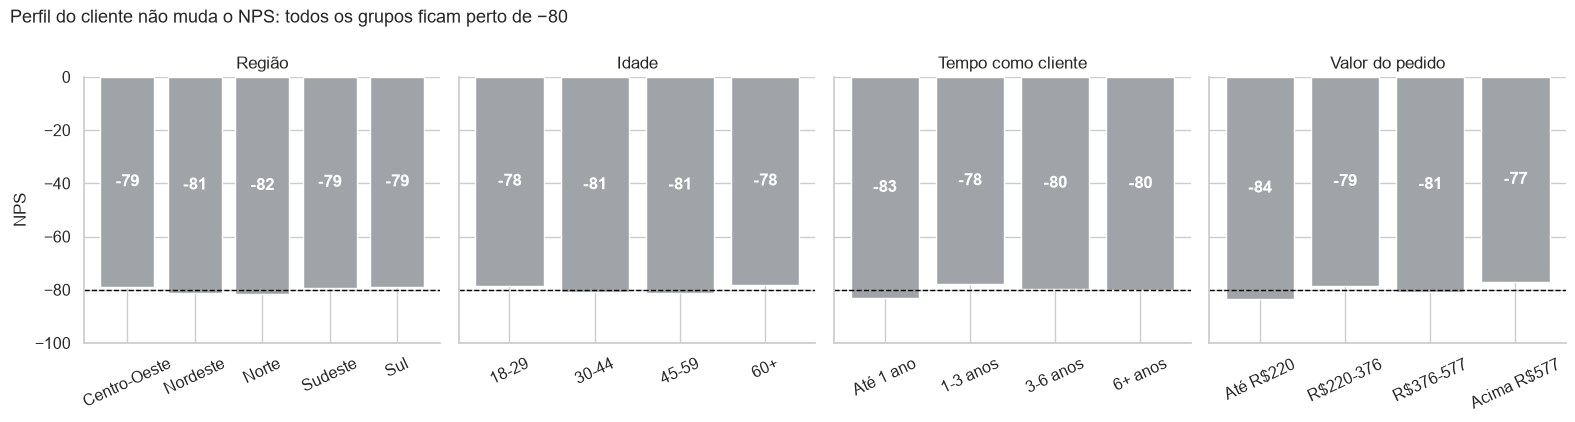

In [11]:
# A faixa de valor do pedido (quartis) já vem da base tratada (src/preparacao.py)
perfis = [
    ("customer_region", "Região"),
    ("faixa_idade", "Idade"),
    ("faixa_tempo_cliente", "Tempo como cliente"),
    ("faixa_valor_pedido", "Valor do pedido"),
]

fig, eixos = plt.subplots(1, 4, figsize=(16, 4.3), sharey=True)
for eixo, (coluna, titulo) in zip(eixos, perfis):
    tabela = resumo_por_grupo(coluna)
    barras = eixo.bar(tabela.index.astype(str), tabela["nps"], color=COR_NEUTRO)
    eixo.bar_label(
        barras,
        labels=[f"{v:.0f}" for v in tabela["nps"]],
        label_type="center",
        color="white",
        fontweight="bold",
    )
    eixo.axhline(nps_geral, color="black", ls="--", lw=1)
    eixo.set_title(titulo)
    eixo.set_ylim(-100, 0)
    eixo.tick_params(axis="x", rotation=25)
eixos[0].set_ylabel("NPS")
fig.suptitle(
    "Perfil do cliente não muda o NPS: todos os grupos ficam perto de −80",
    x=0.01,
    ha="left",
    fontsize=13,
)
salvar_figura("03_07_perfil_cliente.png")
plt.show()

In [12]:
for coluna, titulo in perfis:
    print(f"--- {titulo} ---")
    display(resumo_por_grupo(coluna))

--- Região ---


,clientes,nota_media,pct_detratores,nps
customer_region,,,,
Centro-Oeste,468,4.2,84.0,-78.8
Nordeste,485,4.4,86.0,-81.2
Norte,506,4.4,85.0,-81.6
Sudeste,520,4.4,84.0,-79.2
Sul,521,4.5,83.0,-78.9


--- Idade ---


,clientes,nota_media,pct_detratores,nps
faixa_idade,,,,
18-29,561,4.5,83.0,-78.4
30-44,753,4.3,86.0,-81.0
45-59,723,4.3,85.0,-81.2
60+,463,4.5,83.0,-78.2


--- Tempo como cliente ---


,clientes,nota_media,pct_detratores,nps
faixa_tempo_cliente,,,,
Até 1 ano,242,4.1,86.0,-83.1
1-3 anos,490,4.6,83.0,-78.0
3-6 anos,727,4.4,84.0,-79.9
6+ anos,1041,4.3,85.0,-80.2


--- Valor do pedido ---


,clientes,nota_media,pct_detratores,nps
faixa_valor_pedido,,,,
Até R$220,625,4.2,87.0,-83.5
R$220-376,625,4.5,84.0,-78.6
R$376-577,625,4.3,85.0,-80.8
Acima R$577,625,4.6,82.0,-77.0


In [13]:
# Teste qui-quadrado: a diferença de % de detratores entre os grupos é maior do que o acaso
# explicaria? (p-valor alto = as diferenças são do tamanho que se espera por sorteio)
testes = []
for coluna, titulo in perfis:
    tabela = pd.crosstab(df[coluna], df["flag_detrator"])
    _, p_valor, _, _ = stats.chi2_contingency(tabela)
    testes.append((titulo, round(p_valor, 2)))
pd.DataFrame(testes, columns=["perfil", "p_valor"]).assign(
    leitura=lambda t: np.where(
        t["p_valor"] < NIVEL_SIGNIFICANCIA, "diferença real", "compatível com o acaso"
    )
)

,perfil,p_valor,leitura
0,Região,0.84,compatível com o acaso
1,Idade,0.41,compatível com o acaso
2,Tempo como cliente,0.64,compatível com o acaso
3,Valor do pedido,0.20,compatível com o acaso


**Para o gerente:** **não existe um "tipo de cliente" mais difícil.** Jovem ou idoso, Norte ou Sul, cliente novo ou antigo, compra pequena ou grande: todos ficam com NPS entre −77 e −84. O teste estatístico (qui-quadrado) confirma: em todos os perfis, as diferenças entre grupos são **compatíveis com o acaso** (p-valor acima de 0,05). Qualquer cliente fica satisfeito se a operação funciona, e qualquer cliente fica insatisfeito se ela falha.

O que diferencia os clientes é **a experiência que eles tiveram**:


Jornada perfeita: TODAS as condições -> {'delivery_delay_days': '<= 0', 'complaints_count': '<= 1', 'customer_service_contacts': '<= 1'}
Jornada crítica:  UMA das condições  -> {'delivery_delay_days': '>= 3', 'complaints_count': '>= 6', 'customer_service_contacts': '>= 3'}


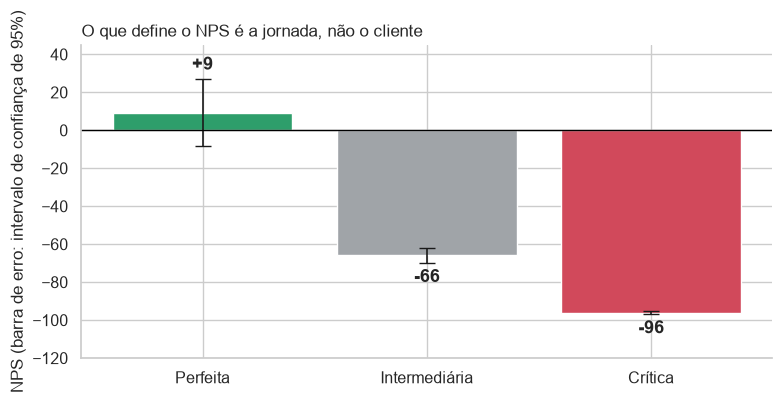

,clientes,nota_media,pct_detratores,nps,pct_clientes,nps_ic95
tipo_jornada,,,,,,
Perfeita,77,8.1,25.0,9.1,3.0,"[-8, +27]"
Intermediária,1065,5.7,73.0,-65.9,43.0,"[-70, -62]"
Crítica,1358,3.1,96.0,-96.0,54.0,"[-97, -95]"


,resolution_time_days,delivery_time_days
flag_detrator,,
0,4.8,8.6
1,7.2,8.4


In [14]:
# tipo_jornada vem da base tratada (src/preparacao.py). Regras:
print(
    "Jornada perfeita: TODAS as condições ->", {c: f"<= {v}" for c, v in JORNADA_PERFEITA.items()}
)
print("Jornada crítica:  UMA das condições  ->", {c: f">= {v}" for c, v in JORNADA_CRITICA.items()})

tabela_jornada = resumo_por_grupo("tipo_jornada")
tabela_jornada["pct_clientes"] = (tabela_jornada["clientes"] / len(df) * 100).round(0)


def intervalo_confianca_nps(notas: pd.Series, n_amostras: int = N_BOOTSTRAP) -> tuple[float, float]:
    """Intervalo de 95% do NPS por bootstrap: reamostra os clientes e recalcula o NPS.

    Com poucos clientes (ex.: 77), o NPS pode oscilar muito de uma amostra para outra.
    O intervalo mostra a faixa em que o NPS "verdadeiro" provavelmente está.
    """
    gerador = np.random.default_rng(SEMENTE)
    valores = notas.to_numpy()
    reamostras = gerador.choice(valores, size=(n_amostras, len(valores)), replace=True)
    nps_amostras = [calcular_nps(amostra) for amostra in reamostras]
    inferior, superior = np.percentile(nps_amostras, [2.5, 97.5])
    return round(inferior), round(superior)


intervalos = df.groupby("tipo_jornada", observed=True)["nps_score"].apply(intervalo_confianca_nps)
tabela_jornada["nps_ic95"] = intervalos.map(lambda ic: f"[{ic[0]:+.0f}, {ic[1]:+.0f}]")
erro_inferior = tabela_jornada["nps"] - intervalos.map(lambda ic: ic[0])
erro_superior = intervalos.map(lambda ic: ic[1]) - tabela_jornada["nps"]

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.bar(
    tabela_jornada.index.astype(str),
    tabela_jornada["nps"],
    color=[COR_PROMOTOR, COR_NEUTRO, COR_DETRATOR],
    yerr=[erro_inferior.to_numpy(), erro_superior.to_numpy()],
    capsize=6,
    error_kw={"lw": 1.2},
)
# Rótulo fora do intervalo de confiança (acima para NPS positivo, abaixo para negativo)
for posicao, (nps, ic) in enumerate(zip(tabela_jornada["nps"], intervalos)):
    acima = nps >= 0
    ax.text(
        posicao,
        ic[1] + 3 if acima else ic[0] - 3,
        f"{nps:+.0f}",
        ha="center",
        va="bottom" if acima else "top",
        fontsize=13,
        fontweight="bold",
    )
ax.axhline(0, color="black", lw=1)
ax.set_title("O que define o NPS é a jornada, não o cliente", loc="left", fontsize=12)
ax.set_ylabel("NPS (barra de erro: intervalo de confiança de 95%)")
ax.set_ylim(-120, 45)
salvar_figura("03_08_nps_por_jornada.png")
plt.show()

display(tabela_jornada)

# Quem é detrator mesmo com jornada perfeita? O tempo de resolução é o que mais difere
perfeita = df["tipo_jornada"] == "Perfeita"
df[perfeita].groupby("flag_detrator")[["resolution_time_days", "delivery_time_days"]].mean().round(
    1
)

**Para o gerente:**
- **Jornada perfeita** (sem atraso, até 1 reclamação e até 1 contato): nota média **8,1** e NPS em torno de **+9**, muito acima do resto. Mas são só **77 clientes (3% da base)**: com tão poucos, o NPS verdadeiro desse grupo pode estar em qualquer ponto entre **−8 e +27** (barra de erro no gráfico). O sinal é claro ("é outro patamar"), o número exato não é. E mesmo aqui **1 em cada 4 ainda é detrator**: entre esses, o tempo de resolução é maior (7,2 contra 4,8 dias), sinal de que há fatores que a base não captura.
- **Jornada crítica** (3+ dias de atraso, **ou** 6+ reclamações, **ou** 3+ contatos): NPS de **−96**, com intervalo estreito (são 1.358 clientes), e ela atinge mais da metade da base.

A empresa **sabe** satisfazer o cliente quando a operação funciona. O problema é que isso acontece com pouca gente.


## 5. E a recompra? Por que não usamos `repeat_purchase_30d`

Seria natural fechar a análise mostrando que "detrator não recompra". Não fazemos isso porque, como mostrado no notebook 02 (seção 9), **`repeat_purchase_30d` é exatamente `nps_score >= 8` em 100% dos pedidos**: a coluna foi derivada da nota. Qualquer gráfico de "recompra por categoria" seria verdadeiro por construção, não uma evidência. O argumento de que satisfação gera recompra fica apoiado na literatura (notebook 01, seção 1.4), e a recomendação para a empresa é **medir a recompra real** nos próximos ciclos, com dados coletados de forma independente da pesquisa.


## Resumo executivo: as respostas para o(a) gerente de operações

| Pergunta | Resposta |
|---|---|
| **Quais fatores são mais críticos?** | **Atraso na entrega** (nº 1), **reclamações**, **contatos repetidos com o atendimento** e **demora na resolução**. Juntos explicam 56% da variação da nota. Preço, frete, desconto e parcelamento quase não pesam. |
| **O que mais gera detratores?** | Atraso de 3+ dias (97–100% detratores), 4+ reclamações (92%+) e 3+ contatos (95%). Quando os problemas se combinam, a nota vai de 8,1 para 0,7. |
| **Existe ponto de ruptura?** | **A nota cai ~1 ponto por dia de atraso desde o 1º dia**; a partir do **3º dia** praticamente todos (97%+) já são detratores. No atendimento, o salto vem com a 2ª reclamação. A ação precisa começar no 1º dia. |
| **Que cliente tem NPS mais alto ou mais baixo?** | **Nenhum perfil se destaca** (região, idade, tempo de casa e ticket dão todos ≈ −80, diferenças compatíveis com o acaso). O que muda o NPS é a **jornada**: perfeita ≈ **+9** (só 3% dos clientes, intervalo −8 a +27), crítica = **−96** (54%). |

**Mensagem central:** a insatisfação não vem de *quem* é o cliente, e sim de *o que acontece* com o pedido dele. Com isso, o problema é **gerenciável pela operação**: cumprir o prazo prometido e resolver na primeira vez.


## Avaliação (CRISP-DM): as metas analíticas foram atingidas?

Voltando à tabela de metas do notebook 01 (seção 1.1):

| Meta analítica | Resultado | Status |
|---|---|---|
| Identificar e ranquear os fatores associados a notas baixas | 4 fatores, todos de entrega e atendimento; juntos explicam 56% da variação da nota | ✅ |
| Encontrar pontos de ruptura para servir de gatilho de alerta | Nota cai ~1 ponto por dia de atraso desde o 1º dia; 95%+ de detratores a partir de 3 dias de atraso, 2 reclamações ou 3 contatos | ✅ |
| Quantificar o impacto por área responsável | Logística: −1 ponto por dia de atraso. Atendimento: −0,4 por reclamação, −0,3 por contato, −0,14 por dia de resolução. Pedido e perfil: sem efeito | ✅ |

**O que não foi possível, e por quê:** provar causalidade (a base é observacional, só mostra associação); analisar evolução no tempo (não há datas); usar a recompra como medida de resultado (a coluna é derivada da nota, notebook 02, seção 9). Essas limitações e a leitura alternativa das colunas de prazo (notebook 02, seção 5.1) ficam registradas nos slides.

## Implantação (CRISP-DM): como a empresa usa isso a partir de amanhã

Todos os gatilhos abaixo usam só informações que **existem durante a jornada**, antes da pesquisa de NPS, que é exatamente o objetivo do projeto: sair do reativo para o proativo.

| Ação | Área | Gatilho | Como medir se funcionou |
|---|---|---|---|
| Alerta no **1º dia de atraso**: avisar o cliente e priorizar a entrega | Logística + CX | `delivery_delay_days >= 1` | % de pedidos que chegam a 3+ dias de atraso; NPS dos pedidos atrasados |
| Fila prioritária no SAC para quem já teve atraso ou reclamação | Atendimento | 1ª reclamação ou 2º contato | Taxa de resolução no 1º contato; nº médio de contatos por pedido |
| Revisar a promessa de prazo: prometer o que dá para cumprir | Logística | % de atraso por rota ou transportadora | OTIF (entregue no prazo e completo) |
| Acompanhar o NPS por **tipo de jornada**, não por perfil de cliente | CX | mensal | % de clientes em jornada perfeita (hoje 3%) |
| Validar causalidade com um teste controlado | CX + Logística | aplicar o alerta do 1º dia em parte dos pedidos e comparar o NPS | diferença de NPS entre os grupos |

➡️ Os gráficos salvos em `reports/figures/` serão usados nos slides.
